<a href="https://colab.research.google.com/github/sevenZHQ1018/Econ5200/blob/lab/class12_lab12_hangqi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
from google.colab import files
uploaded = files.upload()  # 选择并上传两个 CSV 文件
print('Uploaded files:', list(uploaded.keys()))

Saving Zillow_California_2026_Hedonic.csv to Zillow_California_2026_Hedonic (2).csv
Saving Zillow_ZHVI_2026_Micro.csv to Zillow_ZHVI_2026_Micro (3).csv
Uploaded files: ['Zillow_California_2026_Hedonic (2).csv', 'Zillow_ZHVI_2026_Micro (3).csv']


=== Dataset Shape ===
(1000, 5)

=== Column Names ===
['Home_Value', 'Square_Footage', 'Property_Age', 'Distance_to_Transit', 'School_District_Rating']

=== First 5 Rows ===
   Home_Value  Square_Footage  Property_Age  Distance_to_Transit  \
0   329705.74          1941.0           5.5                 6.45   
1   183343.63          1364.3          35.2                 2.15   
2   354551.73          2386.9          52.4                 0.75   
3   325773.17          2192.1          50.2                 5.25   
4   359743.12          3069.8          66.5                12.69   

  School_District_Rating  
0              Excellent  
1                Average  
2                   Good  
3              Excellent  
4              Excellent  

=== Descriptive Statistics ===
          Home_Value  Square_Footage  Property_Age  Distance_to_Transit
count    1000.000000     1000.000000     1000.0000          1000.000000
mean   320008.067140     2244.538300       39.7171             7.587540
std    

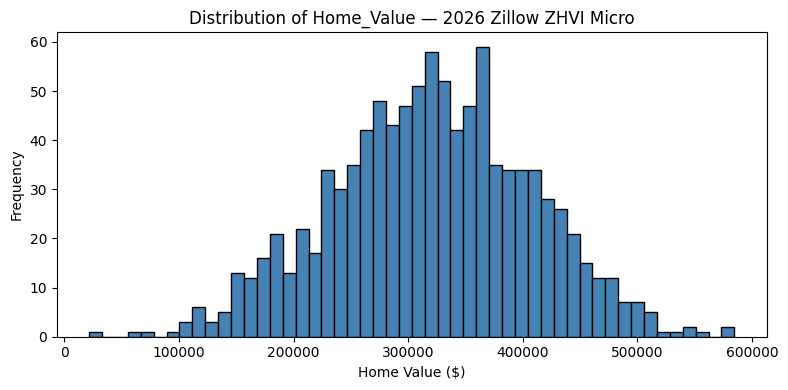


Home_Value Mean:  $320,008.07
Home_Value Std:   $87,569.42
Home_Value Min:   $21,652.58
Home_Value Max:   $584,770.65


In [14]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from statsmodels.tools.eval_measures import rmse
import matplotlib.pyplot as plt

# Step 1: Ingestion from uploaded file
df = pd.read_csv('Zillow_ZHVI_2026_Micro.csv')

# Quick EDA: understand scale and variance of the target variable
print('=== Dataset Shape ===')
print(df.shape)

print('\n=== Column Names ===')
print(df.columns.tolist())

print('\n=== First 5 Rows ===')
print(df.head())

print('\n=== Descriptive Statistics ===')
print(df.describe())

print('\n=== Missing Values ===')
print(df.isnull().sum())

# Distribution of target variable Home_Value
plt.figure(figsize=(8, 4))
plt.hist(df['Home_Value'], bins=50, edgecolor='black', color='steelblue')
plt.title('Distribution of Home_Value — 2026 Zillow ZHVI Micro')
plt.xlabel('Home Value ($)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print(f'\nHome_Value Mean:  ${df["Home_Value"].mean():,.2f}')
print(f'Home_Value Std:   ${df["Home_Value"].std():,.2f}')
print(f'Home_Value Min:   ${df["Home_Value"].min():,.2f}')
print(f'Home_Value Max:   ${df["Home_Value"].max():,.2f}')

In [15]:
# Step 2: Defining the formula
# Utilizing the R-style patsy formula interface allows for elegant, readable model specification
# Format: 'dependent_variable ~ independent_var1 + independent_var2 + ...'
# The intercept is included automatically by patsy
formula = 'Home_Value ~ Square_Footage + Property_Age + Distance_to_Transit'

print('OLS Formula:')
print(formula)
print('\nEconomic intuition check:')
print('  Square_Footage      -> expect POSITIVE coef (larger homes = higher value)')
print('  Property_Age        -> expect NEGATIVE coef (older homes typically depreciate)')
print('  Distance_to_Transit -> expect NEGATIVE coef (farther from transit = lower value)')

OLS Formula:
Home_Value ~ Square_Footage + Property_Age + Distance_to_Transit

Economic intuition check:
  Square_Footage      -> expect POSITIVE coef (larger homes = higher value)
  Property_Age        -> expect NEGATIVE coef (older homes typically depreciate)
  Distance_to_Transit -> expect NEGATIVE coef (farther from transit = lower value)


In [16]:
# Step 3: Fitting the model and printing the summary
model   = smf.ols(formula=formula, data=df)
results = model.fit()

print(results.summary())

print('\n=== Coefficient Sign Check (Economic Intuition) ===')
coef = results.params
expected_signs = {
    'Square_Footage':      'positive',
    'Property_Age':        'negative',
    'Distance_to_Transit': 'negative'
}
for var, expected in expected_signs.items():
    actual_sign = 'positive' if coef[var] > 0 else 'negative'
    match = 'OK' if actual_sign == expected else 'UNEXPECTED - check data'
    print(f'  {var:<25} coef={coef[var]:>10,.4f}  expected={expected:<8}  [{match}]')

                            OLS Regression Results                            
Dep. Variable:             Home_Value   R-squared:                       0.766
Model:                            OLS   Adj. R-squared:                  0.765
Method:                 Least Squares   F-statistic:                     1087.
Date:                Fri, 13 Mar 2026   Prob (F-statistic):          1.73e-313
Time:                        18:53:56   Log-Likelihood:                -12072.
No. Observations:                1000   AIC:                         2.415e+04
Df Residuals:                     996   BIC:                         2.417e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept            8.898e+04   6

In [17]:
# Step 4: Generating predictions
# We extract the predicted values vector to transition from explanation to prediction
y_pred = results.predict(df)

print('=== Predicted Values (first 10) ===')
print(y_pred.head(10).to_numpy())

print('\n=== Actual vs Predicted Comparison (first 10) ===')
actual_10 = df['Home_Value'].head(10).to_numpy()
pred_10   = y_pred.head(10).to_numpy()
comparison = pd.DataFrame({
    'Actual_Home_Value ($)':    actual_10,
    'Predicted_Home_Value ($)': pred_10,
    'Residual ($)':             actual_10 - pred_10
})
print(comparison.to_string(index=False))

=== Predicted Values (first 10) ===
[312391.4143181  222863.86282489 333724.31363089 307478.03931572
 392700.23971878 339170.19519427 256805.34606938 201338.80359579
 369467.04755592 326303.72022125]

=== Actual vs Predicted Comparison (first 10) ===
 Actual_Home_Value ($)  Predicted_Home_Value ($)  Residual ($)
             329705.74             312391.414318  17314.325682
             183343.63             222863.862825 -39520.232825
             354551.73             333724.313631  20827.416369
             325773.17             307478.039316  18295.130684
             359743.12             392700.239719 -32957.119719
             381678.41             339170.195194  42508.214806
             206608.05             256805.346069 -50197.296069
             152588.09             201338.803596 -48750.713596
             364536.13             369467.047556  -4930.917556
             352447.52             326303.720221  26143.799779


In [18]:
# Step 5: Calculate RMSE between the actuals and the predictions
model_rmse = rmse(df['Home_Value'], y_pred)

print(f'\nThe Predictive RMSE is: ${model_rmse:,.2f}')
print(f'\nInterpretation:')
print(f'  On average, this OLS hedonic pricing model deviates from actual')
print(f'  home values by ${model_rmse:,.2f} per prediction.')
print(f'  This is the absolute financial error magnitude of the algorithm.')
print(f'\nModel R-squared: {results.rsquared:.4f}')
print(f'  WARNING: High R-squared alone is insufficient.')
print(f'  A model with high R-squared but large RMSE can lead to catastrophic')
print(f'  financial miscalculations (e.g. overpaying for toxic real estate inventory).')


The Predictive RMSE is: $42,341.60

Interpretation:
  On average, this OLS hedonic pricing model deviates from actual
  home values by $42,341.60 per prediction.
  This is the absolute financial error magnitude of the algorithm.

Model R-squared: 0.7660
  A model with high R-squared but large RMSE can lead to catastrophic
  financial miscalculations (e.g. overpaying for toxic real estate inventory).


In [19]:
import plotly.express as px

# --- Extract residuals and fitted values from the statsmodels results object ---
# results.fittedvalues: in-sample predicted values (y-hat)
# results.resid: residuals  e = y - y-hat
fitted_values = results.fittedvalues
residuals     = results.resid

# --- Compute outlier threshold: 2 standard deviations from mean residual ---
resid_mean  = residuals.mean()
resid_std   = residuals.std()
upper_bound = resid_mean + 2 * resid_std
lower_bound = resid_mean - 2 * resid_std

# --- Label each observation: Outlier if outside +-2sd, else Normal ---
outlier_flag = np.where(
    (residuals > upper_bound) | (residuals < lower_bound),
    'Outlier (>2sd)',
    'Normal'
)

# --- Build the plotting DataFrame ---
plot_df = pd.DataFrame({
    'Fitted_Values': fitted_values.values,
    'Residuals':     residuals.values,
    'Status':        outlier_flag
})

# --- Visual logic: normal = steelblue, outliers = darkred ---
color_map = {'Normal': 'steelblue', 'Outlier (>2sd)': 'darkred'}

fig = px.scatter(
    plot_df,
    x='Fitted_Values',
    y='Residuals',
    color='Status',
    color_discrete_map=color_map,
    title='Residual Forensics Dashboard: Fitted Values vs. Residuals',
    labels={
        'Fitted_Values': 'Fitted (Predicted) Home Value ($)',
        'Residuals':     'Residual Error ($)'
    },
    opacity=0.6,
    template='plotly_white'
)

# --- Horizontal zero line: benchmark for perfect prediction ---
fig.add_hline(
    y=0,
    line_dash='dash',
    line_color='black',
    annotation_text='Zero Residual Line (Perfect Prediction)',
    annotation_position='top right'
)

# --- +-2sd boundary lines to visualize the outlier detection threshold ---
fig.add_hline(y=upper_bound, line_dash='dot', line_color='orange',
              annotation_text='+2sd', annotation_position='bottom right')
fig.add_hline(y=lower_bound, line_dash='dot', line_color='orange',
              annotation_text='-2sd', annotation_position='top right')

fig.update_layout(height=550, legend_title_text='Observation Status')
fig.show()

# --- Outlier count summary ---
n_outliers = (outlier_flag == 'Outlier (>2sd)').sum()
n_total    = len(outlier_flag)
print(f'Outliers detected (>2sd): {n_outliers} / {n_total} ({100*n_outliers/n_total:.1f}%)')
print(f'Upper bound (+2sd): ${upper_bound:,.2f}')
print(f'Lower bound (-2sd): ${lower_bound:,.2f}')

Outliers detected (>2sd): 36 / 1000 (3.6%)
Upper bound (+2sd): $84,725.58
Lower bound (-2sd): $-84,725.58


=== California Dataset Shape: (1000, 3) ===
   Property_Age  Distance_to_Tech_Hub  Sale_Price
0          77.5                  38.1   684100.56
1          11.0                  95.1   413634.22
2          47.7                  73.5   456709.35
3          61.9                  60.3   624533.95
4         100.8                  16.4   870137.54
       Property_Age  Distance_to_Tech_Hub    Sale_Price
count   1000.000000           1000.000000  1.000000e+03
mean      66.408300             49.535200  6.714519e+05
std       28.260748             28.921219  1.810692e+05
min        0.000000              1.500000  2.824052e+05
25%       42.600000             24.375000  5.208879e+05
50%       66.450000             50.150000  6.609126e+05
75%       89.225000             74.725000  8.324626e+05
max      131.600000            100.000000  1.072142e+06


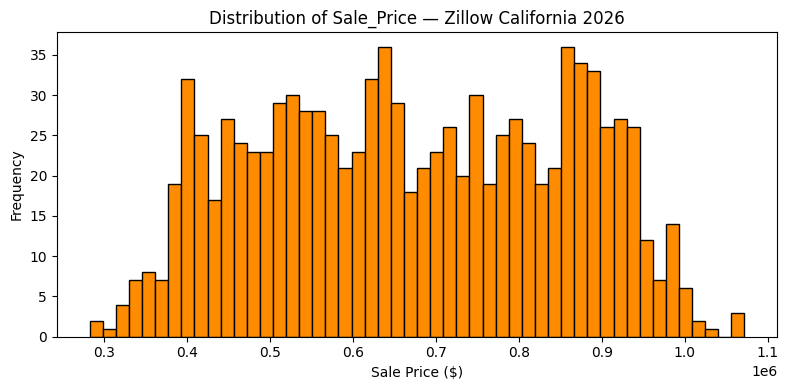


=== California OLS Summary ===
                            OLS Regression Results                            
Dep. Variable:             Sale_Price   R-squared:                       0.954
Model:                            OLS   Adj. R-squared:                  0.954
Method:                 Least Squares   F-statistic:                 1.040e+04
Date:                Fri, 13 Mar 2026   Prob (F-statistic):               0.00
Time:                        18:53:56   Log-Likelihood:                -11982.
No. Observations:                1000   AIC:                         2.397e+04
Df Residuals:                     997   BIC:                         2.399e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------


In [20]:
# Load California hedonic dataset
df_ca = pd.read_csv('Zillow_California_2026_Hedonic.csv')

print('=== California Dataset Shape:', df_ca.shape, '===')
print(df_ca.head())
print(df_ca.describe())

# Distribution of Sale_Price
plt.figure(figsize=(8, 4))
plt.hist(df_ca['Sale_Price'], bins=50, edgecolor='black', color='darkorange')
plt.title('Distribution of Sale_Price — Zillow California 2026')
plt.xlabel('Sale Price ($)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# OLS: Sale_Price ~ Property_Age + Distance_to_Tech_Hub
formula_ca = 'Sale_Price ~ Property_Age + Distance_to_Tech_Hub'
model_ca   = smf.ols(formula=formula_ca, data=df_ca)
results_ca = model_ca.fit()

print('\n=== California OLS Summary ===')
print(results_ca.summary())

# RMSE for California model
y_pred_ca = results_ca.predict(df_ca)
rmse_ca   = rmse(df_ca['Sale_Price'], y_pred_ca)

print(f'\nCalifornia Model RMSE:      ${rmse_ca:,.2f}')
print(f'California Model R-squared: {results_ca.rsquared:.4f}')

print('\nCoefficient Sign Check (California):')
expected_ca = {'Property_Age': 'negative', 'Distance_to_Tech_Hub': 'negative'}
for var, expected in expected_ca.items():
    c = results_ca.params[var]
    actual = 'positive' if c > 0 else 'negative'
    match  = 'OK' if actual == expected else 'UNEXPECTED'
    print(f'  {var:<25} coef={c:>12,.4f}  expected={expected:<8}  [{match}]')

In [21]:
from google.colab import files

uploaded_california = files.upload() # 选择并上传 'Zillow_California_2026_Hedonic.csv'

print('Uploaded files:', list(uploaded_california.keys()))

Saving Zillow_California_2026_Hedonic.csv to Zillow_California_2026_Hedonic (3).csv
Uploaded files: ['Zillow_California_2026_Hedonic (3).csv']
